In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("new_datatrading.csv", sep = ";", quotechar = '"')
data.head()

,Ticket,Open,Type,Volume,Symbol,Price,SL,TP,Close,Price.1,Swap,Commissions,Profit,Pips,Trade duration in seconds
0,35065180,2024-11-18 15:29:28,sell,0.95,USDCAD,1.40844,1.40548,1.40461,2024-11-18 17:51:27,1.40462,0.00,-2.70,244.36,38.2,8519
1,34740588,2024-11-14 15:51:34,buy,0.95,USDCAD,1.40126,1.40126,1.40426,2024-11-14 17:54:42,1.40125,0.00,-2.70,-0.64,-0.1,7388
2,34402413,2024-11-12 15:18:49,buy,0.95,USDCAD,1.39341,1.39341,1.39781,2024-11-13 15:30:08,1.39333,-0.42,-2.68,-5.12,-0.8,87079
3,34540481,2024-11-13 13:54:41,buy,1.42,USDCAD,1.39530,1.39429,0.00000,2024-11-13 15:30:04,1.39420,0.00,-4.00,-105.24,-11.0,5723
4,34052680,2024-11-08 17:35:51,buy,0.95,USDCAD,1.38944,1.38944,1.39397,2024-11-08 19:15:25,1.39217,0.00,-2.66,174.11,27.3,5974


In [4]:
# Vérification des types, ils seront modifiés par la suite

data.dtypes

Ticket                         int64
Open                          object
Type                          object
Volume                       float64
Symbol                        object
Price                        float64
SL                           float64
TP                           float64
Close                         object
Price.1                      float64
Swap                         float64
Commissions                  float64
Profit                       float64
Pips                         float64
Trade duration in seconds      int64
dtype: object

In [5]:
# Vérification de valeurs manquantes

data.isnull().sum()

Ticket                       0
Open                         0
Type                         0
Volume                       0
Symbol                       0
Price                        0
SL                           0
TP                           0
Close                        0
Price.1                      0
Swap                         0
Commissions                  0
Profit                       0
Pips                         0
Trade duration in seconds    0
dtype: int64

In [6]:
# Vérification des doublons

data.duplicated().sum()

0

In [7]:
# Convertir la date et l'heure en type datetime

data["Open"] = pd.to_datetime(data["Open"])
data["Close"] = pd.to_datetime(data["Close"])

# Séparer la date et l'heure dans deux colonnes distinctes pour les colonnes Open et Close

data["Date d'ouverture"] = data["Open"].dt.date
data["Heure d'ouverture"] = data["Open"].dt.time
data["Date de cloture"] = data["Close"].dt.date
data["Heure de cloture"] = data["Close"].dt.time

# Convertir les dates et les heures en type datetime et format Heure, Minutes, Seconde

data["Date d'ouverture"] = pd.to_datetime (data["Date d'ouverture"])
data["Date de cloture"] = pd.to_datetime (data["Date de cloture"])
data["Heure d'ouverture"] = pd.to_datetime(data["Heure d'ouverture"], format ="%H:%M:%S").dt.time
data["Heure de cloture"] = pd.to_datetime(data["Heure de cloture"], format ="%H:%M:%S").dt.time

# Supprimer les colonnes inutiles

data = data.drop(["Open"], axis = 1)
data = data.drop(["Close"], axis = 1)
data = data.drop(["Ticket"], axis = 1)
data = data.drop(["Symbol"], axis = 1)

data.head()

,Type,Volume,Price,SL,TP,Price.1,Swap,Commissions,Profit,Pips,Trade duration in seconds,Date d'ouverture,Heure d'ouverture,Date de cloture,Heure de cloture
0,sell,0.95,1.40844,1.40548,1.40461,1.40462,0.00,-2.70,244.36,38.2,8519,2024-11-18,15:29:28,2024-11-18,17:51:27
1,buy,0.95,1.40126,1.40126,1.40426,1.40125,0.00,-2.70,-0.64,-0.1,7388,2024-11-14,15:51:34,2024-11-14,17:54:42
2,buy,0.95,1.39341,1.39341,1.39781,1.39333,-0.42,-2.68,-5.12,-0.8,87079,2024-11-12,15:18:49,2024-11-13,15:30:08
3,buy,1.42,1.39530,1.39429,0.00000,1.39420,0.00,-4.00,-105.24,-11.0,5723,2024-11-13,13:54:41,2024-11-13,15:30:04
4,buy,0.95,1.38944,1.38944,1.39397,1.39217,0.00,-2.66,174.11,27.3,5974,2024-11-08,17:35:51,2024-11-08,19:15:25


In [8]:
data.dtypes

Type                                 object
Volume                              float64
Price                               float64
SL                                  float64
TP                                  float64
Price.1                             float64
Swap                                float64
Commissions                         float64
Profit                              float64
Pips                                float64
Trade duration in seconds             int64
Date d'ouverture             datetime64[ns]
Heure d'ouverture                    object
Date de cloture              datetime64[ns]
Heure de cloture                     object
dtype: object

In [9]:
# Convertir le type de la colonne Trade duration in seconds =

data["Trade duration"] = pd.to_timedelta(data["Trade duration in seconds"], unit = "s")

# Supprimer la colonne en seconde

data = data.drop(["Trade duration in seconds"], axis = 1)

data.dtypes

Type                          object
Volume                       float64
Price                        float64
SL                           float64
TP                           float64
Price.1                      float64
Swap                         float64
Commissions                  float64
Profit                       float64
Pips                         float64
Date d'ouverture      datetime64[ns]
Heure d'ouverture             object
Date de cloture       datetime64[ns]
Heure de cloture              object
Trade duration       timedelta64[ns]
dtype: object

In [10]:
# Vérification du type

print(type(data["Heure d'ouverture"].iloc[0])) 

<class 'datetime.time'>


In [11]:
data.head()

,Type,Volume,Price,SL,TP,Price.1,Swap,Commissions,Profit,Pips,Date d'ouverture,Heure d'ouverture,Date de cloture,Heure de cloture,Trade duration
0,sell,0.95,1.40844,1.40548,1.40461,1.40462,0.00,-2.70,244.36,38.2,2024-11-18,15:29:28,2024-11-18,17:51:27,0 days 02:21:59
1,buy,0.95,1.40126,1.40126,1.40426,1.40125,0.00,-2.70,-0.64,-0.1,2024-11-14,15:51:34,2024-11-14,17:54:42,0 days 02:03:08
2,buy,0.95,1.39341,1.39341,1.39781,1.39333,-0.42,-2.68,-5.12,-0.8,2024-11-12,15:18:49,2024-11-13,15:30:08,1 days 00:11:19
3,buy,1.42,1.39530,1.39429,0.00000,1.39420,0.00,-4.00,-105.24,-11.0,2024-11-13,13:54:41,2024-11-13,15:30:04,0 days 01:35:23
4,buy,0.95,1.38944,1.38944,1.39397,1.39217,0.00,-2.66,174.11,27.3,2024-11-08,17:35:51,2024-11-08,19:15:25,0 days 01:39:34


(0.0, 200.0)

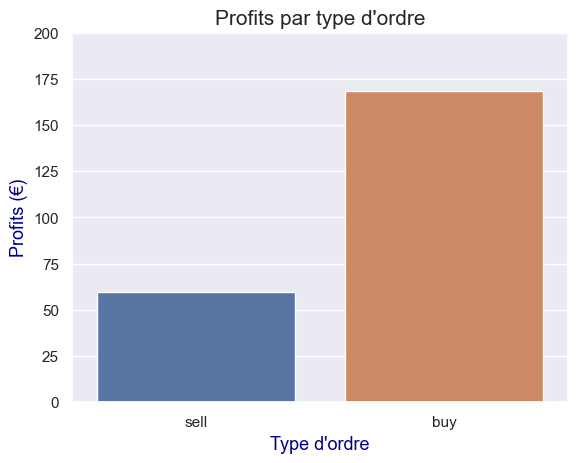

In [163]:
# Graphique pour comparer les profits en fonction des types d'ordres

sns.set_theme()
sns.barplot(data= data, x = "Type", y = "Profit", errorbar = None, estimator = sum, hue = "Type")
plt.title("Profits par type d'ordre", fontsize = 15)
plt.xlabel("Type d'ordre", fontsize = 13, color = "darkblue")
plt.ylabel("Profits (€)", fontsize = 13, color = "darkblue")
plt.ylim(0, 200)

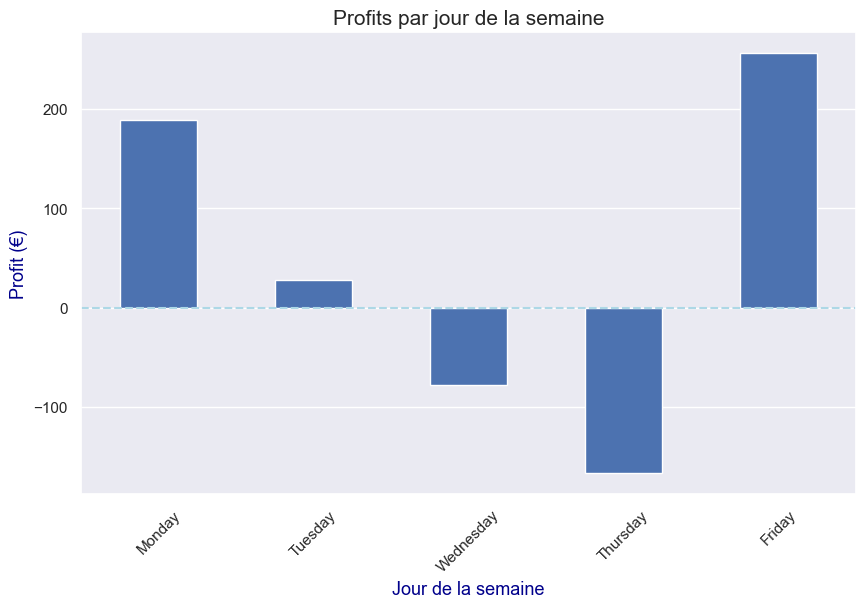

In [13]:
# Graphique pour visualiser quels jours de la semaine j'ai le plus de profit

# Extraire les jours de la semaine
data["Jour de la semaine"] = data["Date de cloture"].dt.day_name()

# Regrouper les profits par jour de la semaine
profits_par_jour = data.groupby("Jour de la semaine")["Profit"].sum()

# Trier les jours de la semaine dans l'ordre
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
profits_par_jour = profits_par_jour.reindex(order)

# Créer le graphique
plt.figure(figsize = (10,6))
profits_par_jour.plot(kind="bar")
plt.title("Profits par jour de la semaine", fontsize = 15)
plt.xlabel("Jour de la semaine", fontsize = 13, color = "darkblue")
plt.ylabel("Profit (€)", fontsize = 13, color = "darkblue")
plt.xticks(rotation=45)
plt.grid ( axis = "x")
plt.axhline(0, color = "lightblue", linestyle = "--")
plt.show()

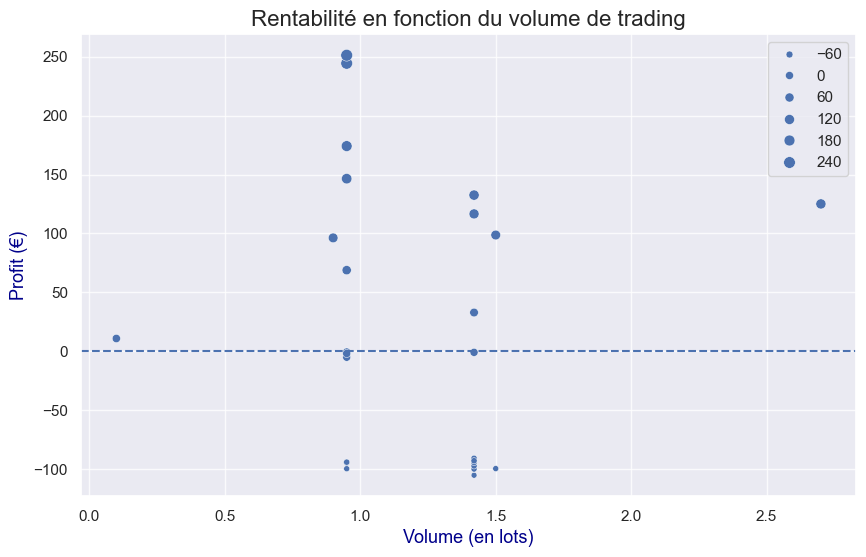

In [137]:
# Graphique pour illustrer la potentielle corrélation entre les lots (volume) que j'utilise et ma rentabilité

sns.set_theme()
plt.figure(figsize = (10,6))
sns.scatterplot(data = data, x=data["Volume"], y=data["Profit"], size = "Profit")
plt.title("Rentabilité en fonction du volume de trading", fontsize=16)
plt.xlabel("Volume (en lots)", fontsize=13, color="darkblue")
plt.ylabel("Profit (€)", fontsize=13, color="darkblue")
plt.axhline(0, linestyle = "--")
plt.grid(alpha=0.8)
plt.legend(bbox_to_anchor = (1, 1))
plt.show()

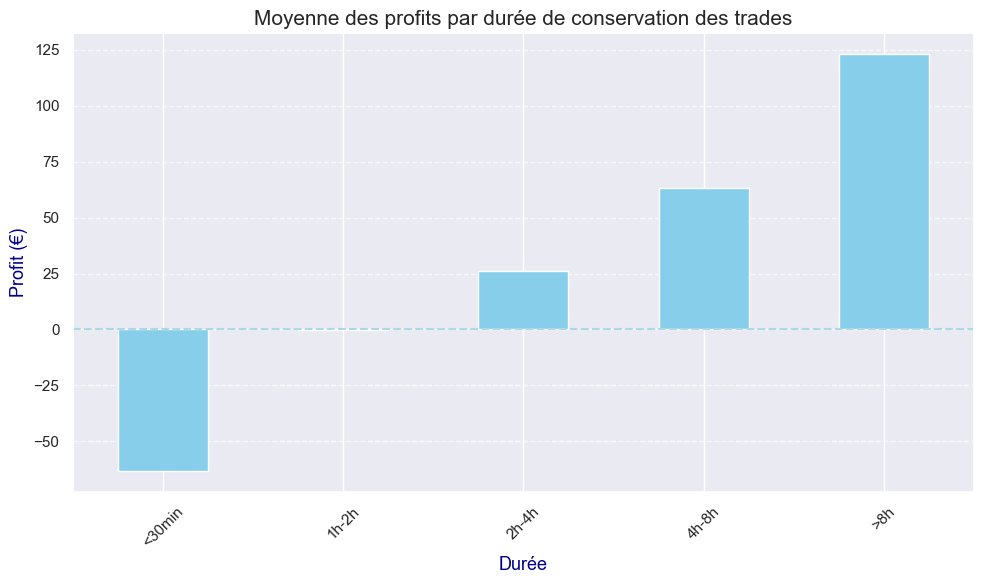

In [167]:
# Graphique pour identifier la durée optimale de conservation des trades

# Définir les catégories basées sur les plages horaires
bins = [0, 0.5, 2, 4, 8, float('inf')]
labels = ["<30min", "1h-2h", "2h-4h", "4h-8h", ">8h"]

# Ajouter une colonne de catégories
data["Duration Category"] = pd.cut(data["Duration (hours)"], bins=bins, labels=labels, right=False)

# Regrouper les profits par catégorie de durée
profits_par_duree = data.groupby("Duration Category", observed=True)["Profit"].mean()

# Créer le graphique
plt.figure(figsize=(10, 6))
profits_par_duree.plot(kind="bar", color="skyblue")
plt.title("Moyenne des profits par durée de conservation des trades", fontsize=15)
plt.xlabel("Durée", fontsize=13, color="darkblue")
plt.ylabel("Profit (€)", fontsize=13, color="darkblue")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.axhline(0, color="lightblue", linestyle="--")
plt.tight_layout()
plt.show()

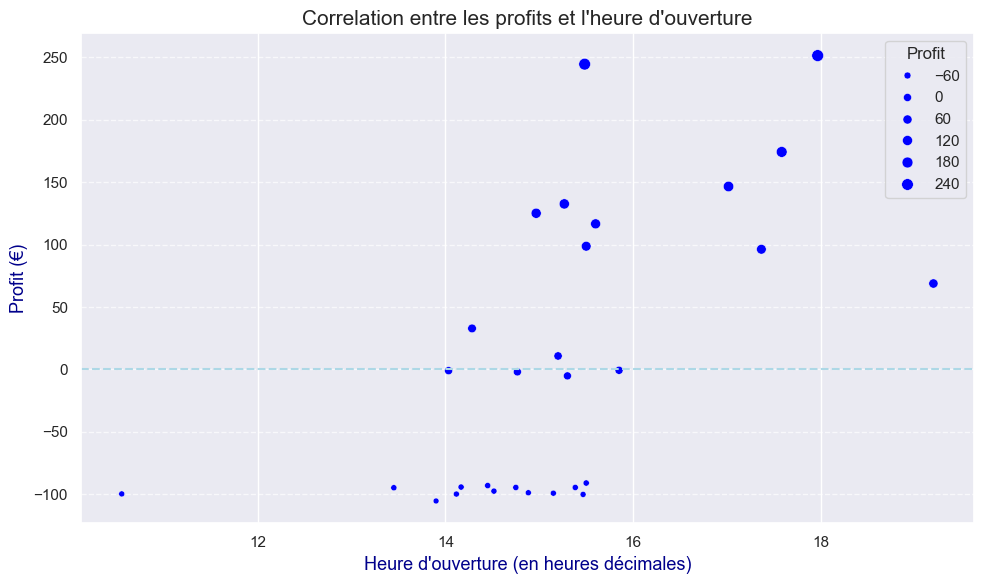

In [157]:
# Graphique pour voir s'il y a une correlation entre mes profits et les heures d'ouverture de mes trades

# Convertir le type d'heure d'ouverture
data["Heure d'ouverture"] = pd.to_datetime(data["Heure d'ouverture"], format="%H:%M:%S")

# Extraire uniquement l'heure sous forme numérique
data["Heure (décimal)"] = data["Heure d'ouverture"].dt.hour + data["Heure d'ouverture"].dt.minute / 60

# Créer le nuage de points
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Heure (décimal)", y="Profit", data=data, color="blue", size = "Profit")
plt.title("Correlation entre les profits et l'heure d'ouverture", fontsize=15)
plt.xlabel("Heure d'ouverture (en heures décimales)", fontsize=13, color="darkblue")
plt.ylabel("Profit (€)", fontsize=13, color="darkblue")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.axhline(0, color="lightblue", linestyle="--")
plt.tight_layout()
plt.show()